# YOLO11-S + DCT Frequency Attention (MultiSpectralAttention): Wildfire Smoke & Fire Detection
**Architecture:** YOLO11-S with a single MultiSpectralAttention (DCT) module injected at L10 — SPPF output (512ch, 20×20)  
**Goal:** Early smoke/fire detection — isolating the SPPF DCT contribution vs. 1×CBAM at SPPF (direct ablation)  
**Datasets:** D-Fire + NEMO + PyroNear (pyro-sdis) → unified corpus of ~55,698 images

---

---
## 1. Setup

In [1]:
!pip install ultralytics pycocotools datasets matplotlib opencv-python-headless -q

import os, gc, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
from pathlib import Path
from PIL import Image
import cv2

print(f"Torch       : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"Device      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print("Libraries loaded ✅")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00
Torch       : 2.10.0+cu128
CUDA        : True
Device      : Tesla T4
Libraries loaded ✅


---
## 2. D-Fire — Load, Filter & Verify

**Source:** `github.com/gaia-solutions-on-demand/DFireDataset` (Kaggle: `sayedgamal99/smoke-fire-detection-yolo`)  
**Size:** 21,527 RGB images, 26,557 bounding boxes — filtered to ~18,700 by rejecting close-up shots  
**Classes:** 0=smoke, 1=fire (author convention)  
**Hard negatives:** ~9,838 images of lamp glare, sun glare, environmental confusion

In [2]:
DFIRE_PATH  = "/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo/data"
CLASS_NAMES = ["smoke", "fire"]
COLORS      = [(0.39, 0.71, 1.0), (1.0, 0.31, 0.0)]

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    if img_dir.exists():
        imgs = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
        lbls = list(lbl_dir.glob("*.txt"))
        print(f"D-Fire {split:5s}: {len(imgs):6d} images | {len(lbls):6d} labels")
    else:
        print(f"D-Fire {split}: path not found")

D-Fire train:  14122 images |  14122 labels
D-Fire val  :   3099 images |   3099 labels
D-Fire test :   4306 images |   4306 labels


In [3]:
def is_distant_shot(label_path, max_box_area=0.40):
    """
    Returns True if image is a distant/tower-camera shot.
    Rejects images where any bounding box covers >40% of the frame.
    Close-up shots (kitchen fires, indoor) have large boxes;
    distant wildfire tower shots have small boxes.
    """
    lbl = Path(label_path)
    if not lbl.exists():
        return True  # no label = negative sample, keep
    with open(lbl) as f:
        lines = f.readlines()
    if not lines or all(l.strip() == '' for l in lines):
        return True  # empty label = negative, keep
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        _, xc, yc, bw, bh = map(float, parts)
        if bw * bh > max_box_area:
            return False
    return True


print("Filtering D-Fire (max box area = 40%)...")
dfire_kept     = {}
dfire_rejected = {}

for split in ["train", "val", "test"]:
    img_dir = Path(DFIRE_PATH) / split / "images"
    lbl_dir = Path(DFIRE_PATH) / split / "labels"
    kept, rejected = [], []
    for img_path in sorted(img_dir.glob("*.jpg")):
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if is_distant_shot(lbl_path):
            kept.append(img_path)
        else:
            rejected.append(img_path)
    dfire_kept[split]     = kept
    dfire_rejected[split] = rejected
    pct = len(rejected) / max(len(kept) + len(rejected), 1) * 100
    print(f"  {split:5s}: kept {len(kept):6d} | rejected {len(rejected):5d} ({pct:.1f}% removed)")

total_kept     = sum(len(v) for v in dfire_kept.values())
total_rejected = sum(len(v) for v in dfire_rejected.values())
print(f"\nTotal kept: {total_kept} | rejected: {total_rejected} "
      f"({total_rejected/(total_kept+total_rejected)*100:.1f}% overall)")

Filtering D-Fire (max box area = 40%)...
  train: kept  12270 | rejected  1852 (13.1% removed)
  val  : kept   2676 | rejected   423 (13.6% removed)
  test : kept   3754 | rejected   552 (12.8% removed)

Total kept: 18700 | rejected: 2827 (13.1% overall)


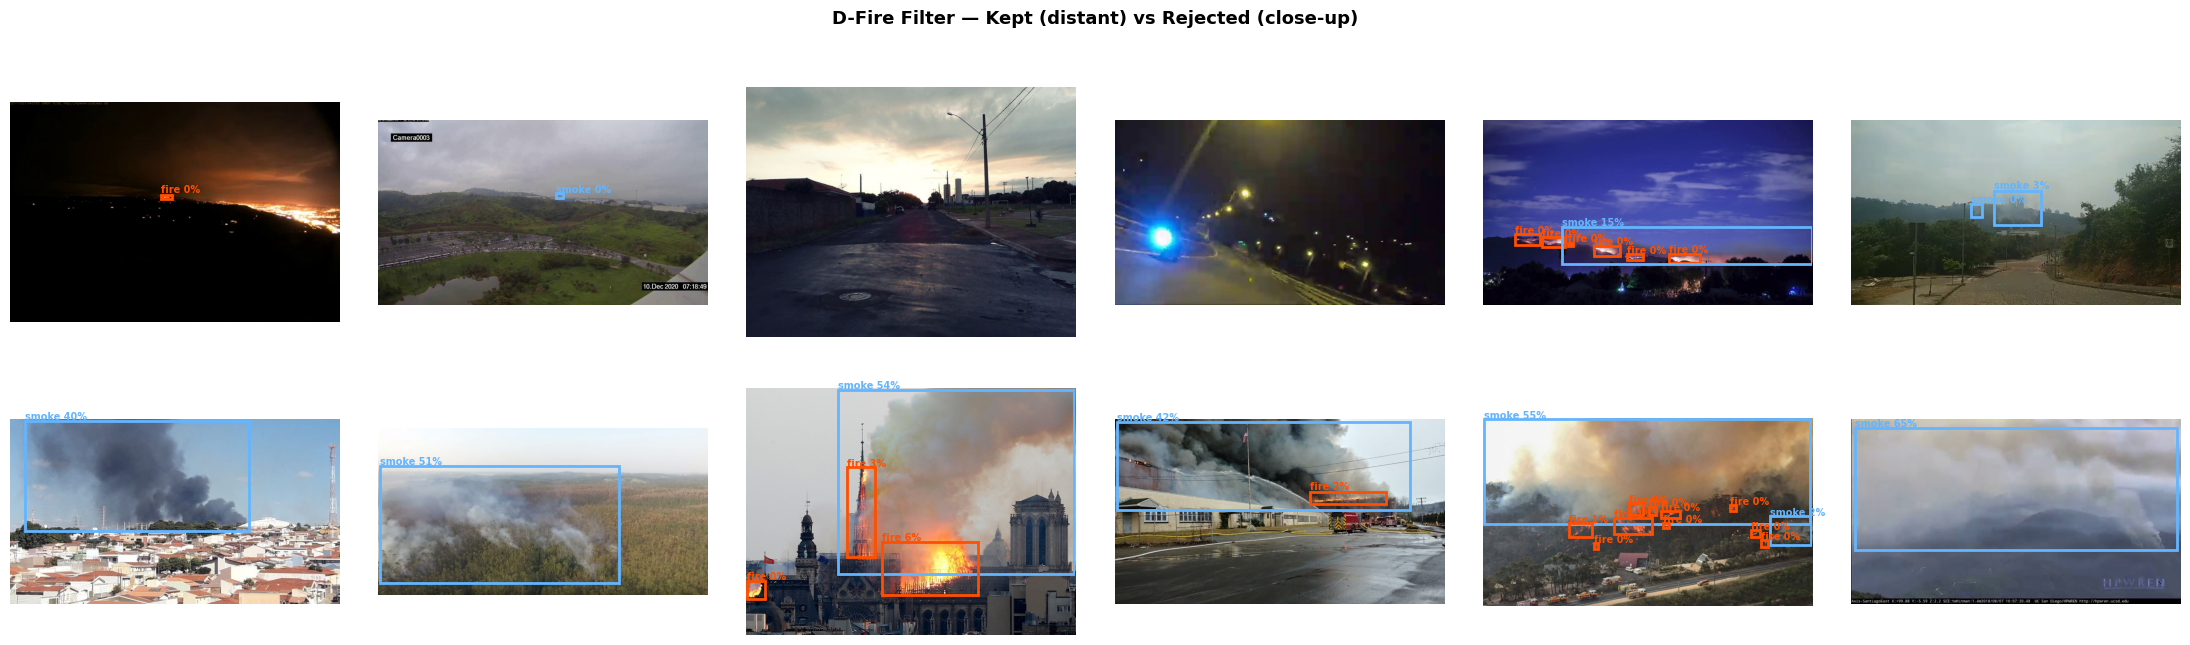

In [4]:
# Visual check: kept (distant) vs rejected (close-up)
def draw_boxes(ax, img_path, lbl_path):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    ax.imshow(img)
    if Path(lbl_path).exists():
        for line in open(lbl_path).readlines():
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, bw, bh = int(parts[0]), *map(float, parts[1:])
            x1, y1 = (xc - bw/2)*W, (yc - bh/2)*H
            c = COLORS[cls % len(COLORS)]
            ax.add_patch(patches.Rectangle((x1, y1), bw*W, bh*H,
                         linewidth=2, edgecolor=c, facecolor='none'))
            ax.text(x1, y1-4, f"{CLASS_NAMES[cls]} {bw*bh*100:.0f}%",
                    color=c, fontsize=7, fontweight='bold')
    ax.axis('off')

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
fig.suptitle("D-Fire Filter — Kept (distant) vs Rejected (close-up)",
             fontsize=13, fontweight='bold')

for i, img_path in enumerate(random.sample(dfire_kept["train"], min(6, len(dfire_kept["train"])))):
    lbl = Path(DFIRE_PATH) / "train" / "labels" / f"{img_path.stem}.txt"
    draw_boxes(axes[0][i], img_path, lbl)
    if i == 0: axes[0][i].set_ylabel("KEPT", fontsize=10, fontweight='bold', color='green')

for i, img_path in enumerate(random.sample(dfire_rejected["train"], min(6, len(dfire_rejected["train"])))):
    lbl = Path(DFIRE_PATH) / "train" / "labels" / f"{img_path.stem}.txt"
    draw_boxes(axes[1][i], img_path, lbl)
    if i == 0: axes[1][i].set_ylabel("REJECTED", fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

---
## 3. NEMO — Convert COCO JSON → YOLO

**Source:** `github.com/SayBender/Nemo` (Kaggle: `werus23/nevada-smoke-detection-data`)  
**Size:** 2,934 images, 4,522 labeled smoke bounding boxes  
**Classes:** Smoke only (low/mid/high density → collapsed to class 0)

In [5]:
NEMO_BASE       = "/kaggle/input/datasets/werus23/nevada-smoke-detection-data"
NEMO_TRAIN_IMGS = f"{NEMO_BASE}/NEMO data/train_images"
NEMO_VAL_IMGS   = f"{NEMO_BASE}/NEMO data/val_images"
NEMO_TRAIN_JSON = f"{NEMO_BASE}/NEMO data/annotation_train.json"
NEMO_VAL_JSON   = f"{NEMO_BASE}/NEMO data/annotation_val.json"
NEMO_2023_IMGS  = f"{NEMO_BASE}/20-23_daytime_images/daytime images"
NEMO_2023_JSON  = f"{NEMO_BASE}/20-23_daytime_label.json"


def coco_to_yolo(json_path, img_src_dir, img_dst_dir, lbl_dst_dir, smoke_class=0):
    """Convert COCO JSON annotations → YOLO format. All smoke classes → class 0."""
    os.makedirs(img_dst_dir, exist_ok=True)
    os.makedirs(lbl_dst_dir, exist_ok=True)
    with open(json_path) as f:
        coco = json.load(f)
    img_map = {img["id"]: img for img in coco["images"]}
    ann_map = {}
    for ann in coco["annotations"]:
        ann_map.setdefault(ann["image_id"], []).append(ann)
    converted = copied = 0
    for img_id, img_info in img_map.items():
        W, H   = img_info["width"], img_info["height"]
        fname  = Path(img_info["file_name"]).stem
        src    = Path(img_src_dir) / Path(img_info["file_name"]).name
        if src.exists():
            shutil.copy2(src, Path(img_dst_dir) / src.name)
            copied += 1
        lines = []
        for ann in ann_map.get(img_id, []):
            x, y, w, h = ann["bbox"]
            xc, yc = (x + w/2)/W, (y + h/2)/H
            wn, hn = w/W, h/H
            lines.append(f"{smoke_class} {xc:.6f} {yc:.6f} {wn:.6f} {hn:.6f}")
        with open(Path(lbl_dst_dir) / f"{fname}.txt", "w") as f:
            f.write("\n".join(lines))
        converted += 1
    print(f"  Converted {converted} labels, copied {copied} images")


print("Converting NEMO train...")
coco_to_yolo(NEMO_TRAIN_JSON, NEMO_TRAIN_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("Converting NEMO val...")
coco_to_yolo(NEMO_VAL_JSON, NEMO_VAL_IMGS,
             "/kaggle/working/nemo_yolo/images/val",
             "/kaggle/working/nemo_yolo/labels/val")

print("Merging 20-23 daytime into train...")
coco_to_yolo(NEMO_2023_JSON, NEMO_2023_IMGS,
             "/kaggle/working/nemo_yolo/images/train",
             "/kaggle/working/nemo_yolo/labels/train")

print("\nNEMO conversion complete:")
for split in ["train", "val"]:
    imgs = list(Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"))
    print(f"  {split}: {len(imgs)} images | {len(lbls)} labels")

Converting NEMO train...
  Converted 2680 labels, copied 2680 images
Converting NEMO val...
  Converted 250 labels, copied 250 images
Merging 20-23 daytime into train...
  Converted 432 labels, copied 432 images

NEMO conversion complete:
  train: 3112 images | 3112 labels
  val: 250 images | 250 labels


---
## 4. PyroNear (pyro-sdis) — Load from HuggingFace & Convert to YOLO

**Source:** `pyronear/pyro-sdis` on HuggingFace (public, no token required)  
**Size:** 33,636 images | Smoke only (class 0) | ~16% hard negatives (empty label files)  
**Camera setup:** Fixed outdoor cameras from SDIS French fire brigade

In [6]:
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient

os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")

print("Loading PyroNear dataset...")
ds = load_dataset("pyronear/pyro-sdis")
print(f"Train samples : {len(ds['train'])}")
print(f"Val samples   : {len(ds['val'])}")

for split_name, split in [("Train", ds["train"]), ("Val", ds["val"])]:
    has_smoke = sum(1 for s in split if s["annotations"] and s["annotations"].strip())
    no_smoke  = len(split) - has_smoke
    print(f"\n{split_name}:")
    print(f"  Smoke positives  : {has_smoke}")
    print(f"  Hard negatives   : {no_smoke} ({no_smoke/len(split):.1%})")

Loading PyroNear dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00006.parquet:   0%|          | 0.00/481M [00:00<?, ?B/s]

data/train-00001-of-00006.parquet:   0%|          | 0.00/485M [00:00<?, ?B/s]

data/train-00002-of-00006.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00005-of-00006.parquet:   0%|          | 0.00/483M [00:00<?, ?B/s]

data/val-00000-of-00001.parquet:   0%|          | 0.00/390M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/29537 [00:00<?, ? examples/s]

Generating val split:   0%|          | 0/4099 [00:00<?, ? examples/s]

Train samples : 29537
Val samples   : 4099

Train:
  Smoke positives  : 24792
  Hard negatives   : 4745 (16.1%)

Val:
  Smoke positives  : 3345
  Hard negatives   : 754 (18.4%)


In [7]:
PYRO_DIRS = {
    "train_imgs": "/kaggle/working/pyro_yolo/images/train",
    "val_imgs":   "/kaggle/working/pyro_yolo/images/val",
    "train_lbls": "/kaggle/working/pyro_yolo/labels/train",
    "val_lbls":   "/kaggle/working/pyro_yolo/labels/val",
}
for d in PYRO_DIRS.values():
    os.makedirs(d, exist_ok=True)


def save_pyro_split(split, img_dir, lbl_dir, split_name):
    for i, sample in enumerate(split):
        img_name = Path(sample["image_name"]).stem
        sample["image"].save(str(Path(img_dir) / f"{img_name}.jpg"))
        ann = sample["annotations"]
        with open(Path(lbl_dir) / f"{img_name}.txt", "w") as f:
            if ann and ann.strip():
                lines = []
                for line in ann.strip().split("\n"):
                    parts = line.strip().split()
                    if len(parts) == 5:
                        _, cx, cy, bw, bh = parts
                        lines.append(f"0 {cx} {cy} {bw} {bh}")
                f.write("\n".join(lines))
        if (i + 1) % 5000 == 0:
            print(f"  {split_name}: {i+1} saved...")
    print(f"  {split_name} done: {len(split)} images")


print("Converting PyroNear train...")
save_pyro_split(ds["train"], PYRO_DIRS["train_imgs"], PYRO_DIRS["train_lbls"], "train")
print("Converting PyroNear val...")
save_pyro_split(ds["val"], PYRO_DIRS["val_imgs"], PYRO_DIRS["val_lbls"], "val")

Converting PyroNear train...
  train: 5000 saved...
  train: 10000 saved...
  train: 15000 saved...
  train: 20000 saved...
  train: 25000 saved...
  train done: 29537 images
Converting PyroNear val...
  val done: 4099 images


---
## 5. Merge → Unified YOLO Dataset

In [8]:
UNIFIED = "/kaggle/working/unified_dataset"

for split in ["train", "val", "test"]:
    Path(f"{UNIFIED}/images/{split}").mkdir(parents=True, exist_ok=True)
    Path(f"{UNIFIED}/labels/{split}").mkdir(parents=True, exist_ok=True)

# ── D-Fire (filtered) ─────────────────────────────────────────────────
print("Copying D-Fire (filtered)...")
for split in ["train", "val", "test"]:
    for img_path in dfire_kept[split]:
        shutil.copy2(img_path, f"{UNIFIED}/images/{split}/dfire_{img_path.name}")
        lbl = Path(f"{DFIRE_PATH}/{split}/labels") / f"{img_path.stem}.txt"
        if lbl.exists():
            shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/dfire_{lbl.name}")
print("  D-Fire ✅")

# ── NEMO ──────────────────────────────────────────────────────────────
print("Copying NEMO...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/nemo_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/nemo_{img.name}")
    for lbl in Path(f"/kaggle/working/nemo_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/nemo_{lbl.name}")
print("  NEMO ✅")

# ── PyroNear ──────────────────────────────────────────────────────────
print("Copying PyroNear...")
for split in ["train", "val"]:
    for img in Path(f"/kaggle/working/pyro_yolo/images/{split}").glob("*.jpg"):
        shutil.copy2(img, f"{UNIFIED}/images/{split}/pyro_{img.name}")
    for lbl in Path(f"/kaggle/working/pyro_yolo/labels/{split}").glob("*.txt"):
        shutil.copy2(lbl, f"{UNIFIED}/labels/{split}/pyro_{lbl.name}")
print("  PyroNear ✅")

# ── Summary ───────────────────────────────────────────────────────────
print("\n── Unified Dataset ──────────────────────────────")
total = 0
for split in ["train", "val", "test"]:
    imgs = list(Path(f"{UNIFIED}/images/{split}").glob("*.jpg"))
    lbls = list(Path(f"{UNIFIED}/labels/{split}").glob("*.txt"))
    pos  = sum(1 for l in lbls if l.read_text().strip())
    neg  = len(lbls) - pos
    print(f"  {split:5s}: {len(imgs):6d} images | "
          f"{pos:6d} positive | {neg:5d} negative ({neg/max(len(lbls),1):.1%})")
    total += len(imgs)
print(f"  TOTAL: {total} images")

print("\n── Source Breakdown ────────────────────────────")
for split in ["train", "val"]:
    dfire = len(list(Path(f"{UNIFIED}/images/{split}").glob("dfire_*")))
    nemo  = len(list(Path(f"{UNIFIED}/images/{split}").glob("nemo_*")))
    pyro  = len(list(Path(f"{UNIFIED}/images/{split}").glob("pyro_*")))
    print(f"  {split}: D-Fire={dfire} | NEMO={nemo} | PyroNear={pyro}")

Copying D-Fire (filtered)...
  D-Fire ✅
Copying NEMO...
  NEMO ✅
Copying PyroNear...
  PyroNear ✅

── Unified Dataset ──────────────────────────────
  train:  44919 images |  33716 positive | 11203 negative (24.9%)
  val  :   7025 images |   4896 positive |  2129 negative (30.3%)
  test :   3754 images |   1749 positive |  2005 negative (53.4%)
  TOTAL: 55698 images

── Source Breakdown ────────────────────────────
  train: D-Fire=12270 | NEMO=3112 | PyroNear=29537
  val: D-Fire=2676 | NEMO=250 | PyroNear=4099


---
## 6. Data YAML + Integrity Check

In [9]:
yaml_content = """# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire
"""

with open("/kaggle/working/data.yaml", "w") as f:
    f.write(yaml_content.strip())
print(yaml_content)

# Unified Fire & Smoke Detection Dataset
# Sources: D-Fire (CC0) + NEMO (open source) + PyroNear/pyro-sdis (Apache 2.0)
# Total: ~55,698 images -- train: 44,919 | val: 7,025 | test: 3,754

path: /kaggle/working/unified_dataset
train: images/train
val:   images/val
test:  images/test

nc: 2
names:
  0: smoke
  1: fire



In [10]:
print("── Dataset Integrity Check ────────────────────────────────────")
for split in ["train", "val", "test"]:
    img_dir = Path(f"{UNIFIED}/images/{split}")
    lbl_dir = Path(f"{UNIFIED}/labels/{split}")
    imgs = {p.stem for p in img_dir.glob("*.jpg")}
    lbls = {p.stem for p in lbl_dir.glob("*.txt")}
    print(f"\n  {split.upper()}")
    print(f"    Images         : {len(imgs)}")
    print(f"    Labels         : {len(lbls)}")
    print(f"    Matched pairs  : {len(imgs & lbls)}")
    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    if imgs_no_lbl: print(f"    ⚠️  Images w/o label: {len(imgs_no_lbl)}")
    if lbls_no_img: print(f"    ⚠️  Labels w/o image: {len(lbls_no_img)}")
    for prefix in ["dfire", "nemo", "pyro"]:
        n_i = len(list(img_dir.glob(f"{prefix}_*.jpg")))
        n_l = len(list(lbl_dir.glob(f"{prefix}_*.txt")))
        mark = "✅" if n_i == n_l else "⚠️"
        print(f"    {mark} {prefix:8s}: {n_i} imgs | {n_l} lbls")

── Dataset Integrity Check ────────────────────────────────────

  TRAIN
    Images         : 44919
    Labels         : 44919
    Matched pairs  : 44919
    ✅ dfire   : 12270 imgs | 12270 lbls
    ✅ nemo    : 3112 imgs | 3112 lbls
    ✅ pyro    : 29537 imgs | 29537 lbls

  VAL
    Images         : 7025
    Labels         : 7025
    Matched pairs  : 7025
    ✅ dfire   : 2676 imgs | 2676 lbls
    ✅ nemo    : 250 imgs | 250 lbls
    ✅ pyro    : 4099 imgs | 4099 lbls

  TEST
    Images         : 3754
    Labels         : 3754
    Matched pairs  : 3754
    ✅ dfire   : 3754 imgs | 3754 lbls
    ✅ nemo    : 0 imgs | 0 lbls
    ✅ pyro    : 0 imgs | 0 lbls


---
## 7. MultiSpectralAttention (DCT Frequency Attention) Module Definition

**Reference:** FcaNet — Qin et al., ICCV 2021 — https://arxiv.org/abs/2012.11879  
**Insertion point:** Layer 10 — immediately after SPPF (layer 9, before C2PSA at layer 11)  
**Channel size:** 512ch (post-scale, gw=0.50) | **Spatial resolution:** 20×20 (640/32)  

**Motivation:** Standard CBAM channel attention uses avg/max pooling — it is *frequency-blind*.  
Atmospheric haze and fog are dominated by **low-frequency, spatially uniform** activations.  
Smoke plumes carry **mid-to-high frequency edges**, directional texture, and irregular boundaries.  
DCT attention learns which spectral components best distinguish smoke from confounders,  
operating at the SPPF bottleneck where the most compressed, globally-aware features live.  

**Parameter cost:** ~2× MLP params vs CBAM channel branch, no spatial branch overhead.

In [11]:
import math
import torch.nn.functional as F

class MultiSpectralAttention(nn.Module):
    """
    DCT-based channel attention (MultiSpectral Channel Attention).
    Based on FcaNet (Qin et al., ICCV 2021 — https://arxiv.org/abs/2012.11879).
    Adapted for wildfire smoke detection at SPPF output (512ch, 20×20 spatial).

    Replaces avg/max pooling in standard CBAM channel attention with a fixed 2D DCT
    filter bank. Each channel is mapped to a distinct spectral component.
    The attention MLP then learns which frequency bands activate for smoke vs haze.

    - Smoke plumes:        mid-to-high frequency edges + irregular texture
    - Fog/haze confounders: low-frequency, spatially uniform activations

    Input/output: same shape (B, C, H, W) — drop-in replacement for CBAM at SPPF.
    No channel change. No spatial branch.
    """
    def __init__(self, channels, dct_h=20, dct_w=20, reduction=16):
        super().__init__()
        self.channels = channels
        self.dct_h    = dct_h
        self.dct_w    = dct_w
        self.inp      = channels  # stored for verification cell

        # Pre-compute fixed 2D DCT filter bank (not learnable)
        # Shape: (channels, dct_h, dct_w)
        dct_weight = self._build_dct_filter(channels, dct_h, dct_w)
        self.register_buffer('dct_weight', dct_weight)

        # Channel attention MLP — receives one spectral coefficient per channel
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    # ------------------------------------------------------------------
    @staticmethod
    def _get_dct_components(num_channels, dct_h, dct_w):
        """
        Generate (u, v) 2D DCT frequency index pairs via zigzag scan
        (sorted by L2 frequency magnitude). Distributes components across
        DC, low, mid, and high frequency bands.
        """
        indices = sorted(
            [(u, v) for u in range(dct_h) for v in range(dct_w)],
            key=lambda x: x[0]**2 + x[1]**2
        )
        return indices[:num_channels]

    @staticmethod
    def _build_dct_filter(channels, dct_h, dct_w):
        """
        Build fixed 2D DCT-II filter bank.
        Returns tensor of shape (channels, dct_h, dct_w).
        Each slice [c, :, :] is the 2D DCT-II basis function for component c.
        """
        components = MultiSpectralAttention._get_dct_components(channels, dct_h, dct_w)
        filters = torch.zeros(channels, dct_h, dct_w)
        for c, (u, v) in enumerate(components):
            for h in range(dct_h):
                for w in range(dct_w):
                    filters[c, h, w] = (
                        math.cos(math.pi * u * (2 * h + 1) / (2 * dct_h)) *
                        math.cos(math.pi * v * (2 * w + 1) / (2 * dct_w))
                    )
        # L2-normalise each filter (zero-norm guard for DC component)
        norms = filters.reshape(channels, -1).norm(dim=1, keepdim=True).clamp(min=1e-8)
        filters = (filters.reshape(channels, -1) / norms).reshape(channels, dct_h, dct_w)
        return filters

    # ------------------------------------------------------------------
    def forward(self, x):
        B, C, H, W = x.shape

        # 1. Resize spatial dims to DCT kernel size if they differ
        if H != self.dct_h or W != self.dct_w:
            x_dct = F.adaptive_avg_pool2d(x, (self.dct_h, self.dct_w))
        else:
            x_dct = x

        # 2. Project each channel onto its assigned DCT basis function
        #    dct_weight: (C, dct_h, dct_w) → (1, C, dct_h, dct_w)
        #    Element-wise multiply + sum over spatial dims → (B, C)
        spectral = (x_dct * self.dct_weight.unsqueeze(0)).sum(dim=(-2, -1))

        # 3. Channel attention MLP on spectral descriptors
        attn = self.fc(spectral)           # (B, C)

        # 4. Recalibrate feature map
        return x * attn.view(B, C, 1, 1)


# ── Sanity check ──────────────────────────────────────────────────────
_x   = torch.randn(2, 512, 20, 20)
_msa = MultiSpectralAttention(channels=512, dct_h=20, dct_w=20)
_out = _msa(_x)
assert _out.shape == _x.shape, "Shape mismatch!"
print(f"Input    : {_x.shape}")
print(f"Output   : {_out.shape}  ✅")
print(f"dct_h/w  : {_msa.dct_h}×{_msa.dct_w}  (matches SPPF output at 640 input: 640/32=20)")
print(f"Params   : {sum(p.numel() for p in _msa.parameters()):,}  (MLP weights only — DCT filter is a fixed buffer)")
print(f"inp attr : {_msa.inp}  ← stored for verification cell")


Input    : torch.Size([2, 512, 20, 20])
Output   : torch.Size([2, 512, 20, 20])  ✅
dct_h/w  : 20×20  (matches SPPF output at 640 input: 640/32=20)
Params   : 32,768  (MLP weights only — DCT filter is a fixed buffer)
inp attr : 512  ← stored for verification cell


---
## 8. Register MultiSpectralAttention into Ultralytics Runtime


In [12]:
import ultralytics.nn.tasks as tasks_mod

# Direct __dict__ injection — most reliable, skips dict scan entirely
tasks_mod.__dict__['MultiSpectralAttention'] = MultiSpectralAttention

# Also register via module_map dict for Ultralytics >= 8.x (defensive)
patched = False
for attr_name in dir(tasks_mod):
    obj = getattr(tasks_mod, attr_name, None)
    if isinstance(obj, dict) and 'C2PSA' in str(obj):
        obj['MultiSpectralAttention'] = MultiSpectralAttention
        print(f"Also patched into tasks_mod.{attr_name} ✅")
        patched = True
        break

if not patched:
    print("module_map dict scan: not found (expected for most versions) ✅")
print("Ultralytics runtime registration complete ✅")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
module_map dict scan: not found (expected for most versions) ✅
Ultralytics runtime registration complete ✅


---
## 9. DCT YAML — Modified YOLO11-S Architecture

**MultiSpectralAttention inserted at L10** — after SPPF (L9), before C2PSA (L11).  
No neck CBAM — clean single-module ablation.  
Detect reads from P3/P4/P5 outputs: **[17, 20, 23]** (indices shift back vs 2×CBAM by removing P4 CBAM).  
Only a **+1 index offset** throughout (one inserted module at L10).  


In [13]:
dct_yaml_str = """
# YOLO11-S + 1×DCT (MultiSpectralAttention at SPPF)
# Reference: FcaNet — Qin et al., ICCV 2021 (https://arxiv.org/abs/2012.11879)
# Placement:
#   L10 — MultiSpectralAttention [512ch] after SPPF, before C2PSA
#          Replaces 1×CBAM at SPPF (ablation baseline: mAP 0.755, PyroNear recall 0.905, FP 0.601)
# Detect reads from P3/P4/P5 outputs: [17, 20, 23] — no neck CBAM, clean comparison

nc: 2  # smoke=0, fire=1

scales:
  s: [0.50, 0.50, 1024]

backbone:
  - [-1, 1, Conv,  [64, 3, 2]]           # 0  P1/2
  - [-1, 1, Conv,  [128, 3, 2]]          # 1  P2/4
  - [-1, 2, C3k2,  [256, False, 0.25]]   # 2
  - [-1, 1, Conv,  [256, 3, 2]]          # 3  P3/8
  - [-1, 2, C3k2,  [512, False, 0.25]]   # 4  P3 skip
  - [-1, 1, Conv,  [512, 3, 2]]          # 5  P4/16
  - [-1, 2, C3k2,  [512, True]]          # 6  P4 skip
  - [-1, 1, Conv,  [1024, 3, 2]]         # 7  P5/32
  - [-1, 2, C3k2,  [1024, True]]         # 8
  - [-1, 1, SPPF,  [1024, 5]]            # 9
  - [-1, 1, MultiSpectralAttention, [512]]  # 10  DCT Frequency Attention ← replaces CBAM
  - [-1, 2, C2PSA, [1024]]               # 11

head:
  - [-1,       1, nn.Upsample, [None, 2, nearest]]  # 12
  - [[-1, 6],  1, Concat,      [1]]                 # 13  cat P4 skip (layer 6)
  - [-1,       2, C3k2,        [512, False]]         # 14

  - [-1,       1, nn.Upsample, [None, 2, nearest]]  # 15
  - [[-1, 4],  1, Concat,      [1]]                 # 16  cat P3 skip (layer 4)
  - [-1,       2, C3k2,        [256, False]]         # 17  P3 output  ← Detect[0]

  - [-1,       1, Conv,        [256, 3, 2]]          # 18
  - [[-1, 14], 1, Concat,      [1]]                  # 19  cat neck-P4 (layer 14)
  - [-1,       2, C3k2,        [512, False]]          # 20  P4 output  ← Detect[1] (no CBAM)

  - [-1,       1, Conv,        [512, 3, 2]]           # 21
  - [[-1, 11], 1, Concat,      [1]]                   # 22  cat C2PSA (layer 11)
  - [-1,       2, C3k2,        [1024, True]]           # 23  P5 output  ← Detect[2]

  - [[17, 20, 23], 1, Detect, [nc]]                   # 24
"""

with open("/kaggle/working/yolo11s_dct_sppf.yaml", "w") as f:
    f.write(dct_yaml_str.strip())
print("yolo11s_dct_sppf.yaml written ✅")

# ── Architecture verification ──────────────────────────────────────────
from ultralytics import YOLO
verify_model = YOLO("/kaggle/working/yolo11s_dct_sppf.yaml")

msa_count = 0
print("\nLayer index | Type")
print("-" * 40)
for i, layer in enumerate(verify_model.model.model):
    ltype = type(layer).__name__
    is_msa = ltype == 'MultiSpectralAttention'
    marker = " ← DCT-MSA" if is_msa else ""
    if is_msa:
        msa_count += 1
        ch = getattr(layer, 'inp', 'N/A')
        marker += f" [inp={ch}]"
    print(f"  [{i:2d}]  {ltype}{marker}")

print(f"\nDCT-MSA modules : {msa_count} (expected 1)")
assert msa_count == 1, f"Expected 1 MSA, found {msa_count}"

# Verify nc and detect indices
nc_check = verify_model.model.yaml['nc']
print(f"nc              : {nc_check} (expected 2)")
assert nc_check == 2, f"nc mismatch: {nc_check}"
print("Architecture verified ✅")
del verify_model


yolo11s_dct_sppf.yaml written ✅

Layer index | Type
----------------------------------------
  [ 0]  Conv
  [ 1]  Conv
  [ 2]  C3k2
  [ 3]  Conv
  [ 4]  C3k2
  [ 5]  Conv
  [ 6]  C3k2
  [ 7]  Conv
  [ 8]  C3k2
  [ 9]  SPPF
  [10]  MultiSpectralAttention ← DCT-MSA [inp=512]
  [11]  C2PSA
  [12]  Upsample
  [13]  Concat
  [14]  C3k2
  [15]  Upsample
  [16]  Concat
  [17]  C3k2
  [18]  Conv
  [19]  Concat
  [20]  C3k2
  [21]  Conv
  [22]  Concat
  [23]  C3k2
  [24]  Detect

DCT-MSA modules : 1 (expected 1)
nc              : 2 (expected 2)
Architecture verified ✅


---
## 10. Transfer Baseline Weights → DCT Model

Cold start from `yolo11s.pt` — **do NOT transfer from any locally trained checkpoint**.  
All vanilla backbone and head layers warm-start from the ImageNet-pretrained weights.  
The MultiSpectralAttention module at L10 initialises randomly (DCT filter is a fixed buffer).  

**Index shift:** only **+1** throughout (one inserted module at L10). No P4 CBAM shift.  
- Vanilla L0–9  → DCT L0–9  (+0, before insertion point)  
- Vanilla L10–22 → DCT L11–23 (+1, after DCT-MSA at L10)  
- Vanilla L23 (Detect nc=80) → skipped (nc mismatch, expected)  


In [14]:
from ultralytics import YOLO
import torch

print("Building YOLO11-S + DCT-MSA and transferring weights from yolo11s.pt...")

# 1. Fresh skeleton from DCT YAML
dct_model = YOLO("/kaggle/working/yolo11s_dct_sppf.yaml")

# 2. Donor weights — vanilla yolo11s.pt (nc=80, no custom modules)
base_model      = YOLO("yolo11s.pt")
base_state_dict = base_model.model.state_dict()
dct_state_dict  = dct_model.model.state_dict()

# 3. Layer index remapping
# Only a single +1 shift — one MultiSpectralAttention inserted at L10.
# No P4 CBAM shift (unlike 2×CBAM which added a second offset).
#
#   Vanilla L0–9   → DCT L0–9    (+0)
#   Vanilla L10–22 → DCT L11–23  (+1, DCT-MSA at L10)
#   Vanilla L23    → skipped      (Detect nc=80 → 2, shape mismatch)

def remap_idx(base_idx):
    if base_idx <= 9:
        return base_idx          # before DCT insertion point
    else:
        return base_idx + 1      # +1 only — single DCT-MSA at L10


transferred     = 0
skipped_shape   = 0
skipped_missing = 0

for k, v in base_state_dict.items():
    parts = k.split('.')
    if len(parts) > 1 and parts[1].isdigit():
        parts[1] = str(remap_idx(int(parts[1])))
        new_key  = '.'.join(parts)
    else:
        new_key = k

    if new_key not in dct_state_dict:
        skipped_missing += 1
        continue
    if dct_state_dict[new_key].shape != v.shape:
        skipped_shape += 1
        continue

    dct_state_dict[new_key] = v
    transferred += 1

dct_model.model.load_state_dict(dct_state_dict, strict=False)

print(f"Transferred           : {transferred} weight tensors")
print(f"Skipped (shape)       : {skipped_shape}  ← Detect nc=80→2, expected")
print(f"Skipped (key missing) : {skipped_missing}  ← DCT-MSA MLP → random init (DCT filter = fixed buffer)")
print()
print("Warm-started : backbone L0–L9, C2PSA L11, neck L12–L23")
print("Random init  : MultiSpectralAttention fc MLP [L10] | Detect head [L24] (nc=2)")
print("Fixed buffer : dct_weight in MultiSpectralAttention (pre-computed, not trained)")

dct_model.save("/kaggle/working/dct_sppf_init.pt")
print("\nSaved → /kaggle/working/dct_sppf_init.pt ✅")
del base_model


Building YOLO11-S + DCT-MSA and transferring weights from yolo11s.pt...
Transferred           : 493 weight tensors
Skipped (shape)       : 6  ← Detect nc=80→2, expected
Skipped (key missing) : 0  ← DCT-MSA MLP → random init (DCT filter = fixed buffer)

Warm-started : backbone L0–L9, C2PSA L11, neck L12–L23
Random init  : MultiSpectralAttention fc MLP [L10] | Detect head [L24] (nc=2)
Fixed buffer : dct_weight in MultiSpectralAttention (pre-computed, not trained)

Saved → /kaggle/working/dct_sppf_init.pt ✅


---
## 11. Train YOLO11-S + DCT-MSA (SPPF)


In [15]:
dct_model = YOLO("/kaggle/working/dct_sppf_init.pt")

results_dct = dct_model.train(
    data     = "/kaggle/working/data.yaml",
    epochs   = 30,
    imgsz    = 640,
    batch    = 16,
    device   = 0,
    project  = "/kaggle/working/runs",
    name     = "yolo11s_dct_sppf",
    save     = True,
    plots    = True
)

shutil.make_archive("/kaggle/working/yolo11s_dct_sppf_results", "zip",
                    "/kaggle/working/runs/yolo11s_dct_sppf")
print("DCT-MSA training complete — results zipped ✅")


Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/dct_sppf_init.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_dct_sppf, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

---
## 12. Training Curves


── Per-epoch summary ──────────────────────────────────────────
 epoch  train/box_loss  val/box_loss  metrics/mAP50(B)  metrics/precision(B)  metrics/recall(B)
     1         1.81895       1.72598           0.43948               0.47677            0.49091
     2         1.87407       1.74073           0.41441               0.48643            0.45049
     3         1.94345       1.74458           0.40043               0.46604            0.43129
     4         1.90445       1.59996           0.49583               0.53630            0.52484
     5         1.79367       1.51639           0.55726               0.60283            0.54360
     6         1.73105       1.47891           0.57228               0.59663            0.55791
     7         1.67737       1.42550           0.60184               0.60652            0.58901
     8         1.64201       1.39326           0.63137               0.63778            0.60426
     9         1.61389       1.37649           0.63649               0.6

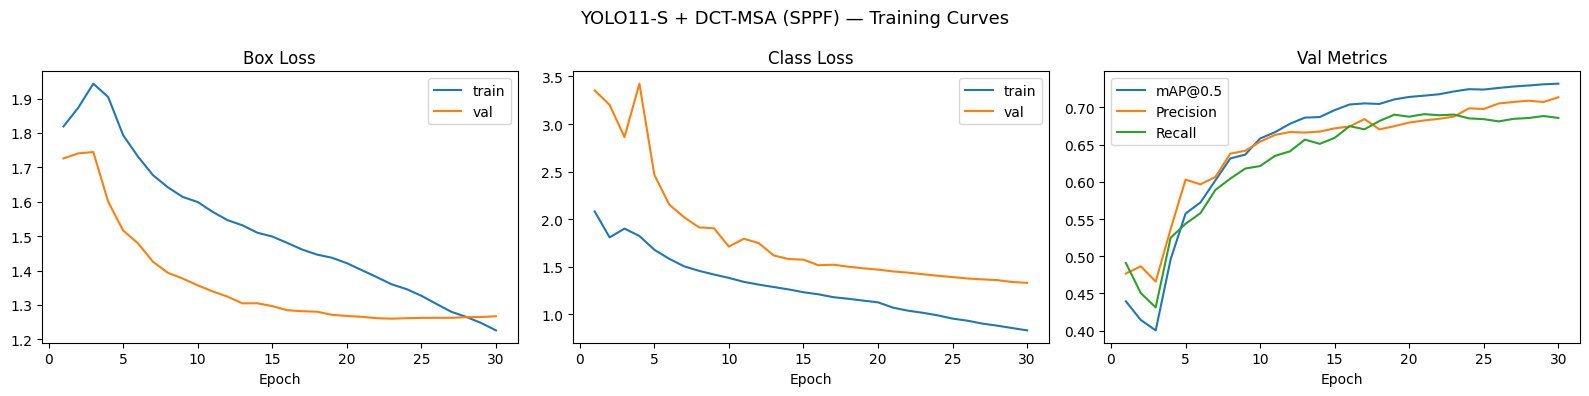

In [16]:
DCT_DIR  = "/kaggle/working/runs/yolo11s_dct_sppf"
BEST_PT  = f"{DCT_DIR}/weights/best.pt"

df = pd.read_csv(f"{DCT_DIR}/results.csv")
df.columns = df.columns.str.strip()

print("── Per-epoch summary ──────────────────────────────────────────")
print(df[["epoch",
          "train/box_loss", "val/box_loss",
          "metrics/mAP50(B)",
          "metrics/precision(B)",
          "metrics/recall(B)"]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("YOLO11-S + DCT-MSA (SPPF) — Training Curves", fontsize=13)

axes[0].plot(df["epoch"], df["train/box_loss"], label="train")
axes[0].plot(df["epoch"], df["val/box_loss"],   label="val")
axes[0].set_title("Box Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(df["epoch"], df["train/cls_loss"], label="train")
axes[1].plot(df["epoch"], df["val/cls_loss"],   label="val")
axes[1].set_title("Class Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(df["epoch"], df["metrics/mAP50(B)"],     label="mAP@0.5")
axes[2].plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
axes[2].plot(df["epoch"], df["metrics/recall(B)"],    label="Recall")
axes[2].set_title("Val Metrics"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout()
plt.savefig("/kaggle/working/dct_sppf_training_curves.png", dpi=120)
plt.show()

---
## 13. Evaluation

Three evaluation passes:
- **Eval A** — D-Fire test set (3,754 images) — cross-dataset generalization
- **Eval B** — Combined val set (7,025 images) — all three source distributions
- **Eval C** — PyroNear val only — in-distribution tower camera performance

In [17]:
# Full memory reset before evaluation
try:
    del dct_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print(f"VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB ✅")

eval_model = YOLO(BEST_PT)
lbl_test   = Path(f"{UNIFIED}/labels/test")
img_test   = Path(f"{UNIFIED}/images/test")
lbl_val    = Path(f"{UNIFIED}/labels/val")
img_val    = Path(f"{UNIFIED}/images/val")


def batched_fp_rate(model, hard_neg_imgs, batch_size=200):
    """Compute FP rate on hard negative images in batches to avoid OOM."""
    fp = 0
    for i in range(0, len(hard_neg_imgs), batch_size):
        preds = model.predict(source=hard_neg_imgs[i:i+batch_size],
                              imgsz=640, conf=0.25, device=0, verbose=False)
        fp += sum(1 for r in preds if len(r.boxes) > 0)
        torch.cuda.empty_cache()
    return fp, fp / len(hard_neg_imgs) if hard_neg_imgs else 0


def get_hard_negs(img_dir, lbl_dir):
    return [
        str(img_dir / lbl.with_suffix(".jpg").name)
        for lbl in lbl_dir.glob("*.txt")
        if lbl.read_text().strip() == ""
        and (img_dir / lbl.with_suffix(".jpg").name).exists()
    ]

VRAM free: 15.4 GB ✅


In [18]:
# ════════════════════════════════════════════════════════════════════
# EVAL A — D-Fire Test Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL A: D-Fire Test Set ────────────────────────────────────")
metrics_A = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "test",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = DCT_DIR,
    name     = "eval_A_dfire_test",
    exist_ok = True,
)

map50_A, map5095_A = metrics_A.box.map50, metrics_A.box.map
prec_A,  rec_A     = metrics_A.box.mp,    metrics_A.box.mr

print(f"  mAP@0.5      : {map50_A:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_A:.4f}")
print(f"  Precision    : {prec_A:.4f}")
print(f"  Recall       : {rec_A:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_A.box.ap50[i]:.4f}")

hard_neg_A       = get_hard_negs(img_test, lbl_test)
fp_A, fp_rate_A  = batched_fp_rate(eval_model, hard_neg_A)
print(f"\n  Hard negatives: {len(hard_neg_A)}")
print(f"  False positives: {fp_A}")
print(f"  FP Rate        : {fp_rate_A:.4f} ({fp_rate_A*100:.1f}%)")

── EVAL A: D-Fire Test Set ────────────────────────────────────
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s_dct_sppf summary (fused): 105 layers, 9,446,342 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 15.3±15.0 MB/s, size: 102.6 KB)
val: Scanning /kaggle/working/unified_dataset/labels/test... 3754 images, 2005 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3754/3754 744.3it/s 5.0s
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11243.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11244.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11245.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11313.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/test/dfire_WEB11315.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unifie

In [19]:
# ════════════════════════════════════════════════════════════════════
# EVAL B — Combined Val Set
# ════════════════════════════════════════════════════════════════════
print("── EVAL B: Combined Val Set ───────────────────────────────────")
torch.cuda.empty_cache()
metrics_B = eval_model.val(
    data     = "/kaggle/working/data.yaml",
    split    = "val",
    imgsz    = 640,
    batch    = 8,
    device   = 0,
    plots    = True,
    project  = DCT_DIR,
    name     = "eval_B_combined_val",
    exist_ok = True,
)

map50_B, map5095_B = metrics_B.box.map50, metrics_B.box.map
prec_B,  rec_B     = metrics_B.box.mp,    metrics_B.box.mr

print(f"  mAP@0.5      : {map50_B:.4f}")
print(f"  mAP@0.5:0.95 : {map5095_B:.4f}")
print(f"  Precision    : {prec_B:.4f}")
print(f"  Recall       : {rec_B:.4f}")
print("  Per-class AP@0.5:")
for i, cls in enumerate(["smoke", "fire"]):
    print(f"    {cls:6s}: {metrics_B.box.ap50[i]:.4f}")

hard_neg_B       = get_hard_negs(img_val, lbl_val)
fp_B, fp_rate_B  = batched_fp_rate(eval_model, hard_neg_B)
print(f"\n  Hard negatives: {len(hard_neg_B)}")
print(f"  False positives: {fp_B}")
print(f"  FP Rate        : {fp_rate_B:.4f} ({fp_rate_B*100:.1f}%)")

── EVAL B: Combined Val Set ───────────────────────────────────
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2161.0±1508.2 MB/s, size: 187.1 KB)
val: Scanning /kaggle/working/unified_dataset/labels/val.cache... 7025 images, 2129 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7025/7025 2.0Git/s 0.0s
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07536.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07539.jpg: corrupt JPEG restored and saved
val: /kaggle/working/unified_dataset/images/val/dfire_WEB07561.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 879/879 13.5it/s 1:05
                   all       7025       7079      0.714      0.686      0.733      0.426
                 smoke       4733       5668      0.701      0.728       0.74      0.449
         

In [20]:
# ════════════════════════════════════════════════════════════════════
# EVAL C — PyroNear Val Only (tower camera, in-distribution)
# ════════════════════════════════════════════════════════════════════
print("── EVAL C: PyroNear Val (tower cameras) ───────────────────────")
pyro_val_imgs = sorted(img_val.glob("pyro_*.jpg"))
pyro_val_lbls = [lbl_val / p.with_suffix(".txt").name for p in pyro_val_imgs]
pyro_pos      = sum(1 for l in pyro_val_lbls if l.exists() and l.read_text().strip())
pyro_neg      = sum(1 for l in pyro_val_lbls if l.exists() and not l.read_text().strip())
print(f"  Total images    : {len(pyro_val_imgs)}")
print(f"  Positives       : {pyro_pos}")
print(f"  Hard negatives  : {pyro_neg}")

tp_C = fp_C = fn_C = 0
BATCH = 200
for i in range(0, len(pyro_val_imgs), BATCH):
    chunk_imgs = [str(p) for p in pyro_val_imgs[i:i+BATCH]]
    chunk_lbls = pyro_val_lbls[i:i+BATCH]
    preds = eval_model.predict(source=chunk_imgs, imgsz=640,
                               conf=0.25, device=0, verbose=False)
    for pred, lbl_path in zip(preds, chunk_lbls):
        has_gt  = lbl_path.exists() and lbl_path.read_text().strip() != ""
        has_det = len(pred.boxes) > 0
        if     has_gt and     has_det: tp_C += 1
        elif   has_gt and not has_det: fn_C += 1
        elif not has_gt and   has_det: fp_C += 1
    torch.cuda.empty_cache()

fp_rate_C = fp_C / pyro_neg if pyro_neg else 0
recall_C  = tp_C / pyro_pos if pyro_pos else 0
print(f"\n  True Positives     : {tp_C}")
print(f"  False Positives    : {fp_C}")
print(f"  False Negatives    : {fn_C}")
print(f"  FP Rate            : {fp_rate_C:.4f} ({fp_rate_C*100:.1f}%)")
print(f"  Image-level Recall : {recall_C:.4f} ({recall_C*100:.1f}%)")

── EVAL C: PyroNear Val (tower cameras) ───────────────────────
  Total images    : 4099
  Positives       : 3345
  Hard negatives  : 754

  True Positives     : 3055
  False Positives    : 465
  False Negatives    : 290
  FP Rate            : 0.6167 (61.7%)
  Image-level Recall : 0.9133 (91.3%)


---
## 14. Results Summary & Save


In [21]:
print("\n" + "="*65)
print(" RESULTS — YOLO11-S + DCT-MSA (SPPF)")
print("="*65)
print(f"  {'Eval':<35} {'mAP@0.5':>8} {'Prec':>8} {'Rec':>8} {'FP Rate':>8}")
print(f"  {'-'*65}")
print(f"  {'A: D-Fire test  (cross-dataset)':<35} {map50_A:>8.4f} {prec_A:>8.4f} {rec_A:>8.4f} {fp_rate_A:>8.4f}")
print(f"  {'B: Combined val (all datasets)':<35} {map50_B:>8.4f} {prec_B:>8.4f} {rec_B:>8.4f} {fp_rate_B:>8.4f}")
print(f"  {'C: PyroNear val (tower only)':<35} {'—':>8} {'—':>8} {recall_C:>8.4f} {fp_rate_C:>8.4f}")
print("="*65)

dct_results = {
    "model"                   : "YOLO11-S + DCT-MSA (SPPF)",
    "train_data"              : "unified (55,698)",
    "params"                  : "~9.4M + CBAM",
    # Eval A
    "mAP50_dfire_test"        : round(float(map50_A),    4),
    "mAP5095_dfire_test"      : round(float(map5095_A),  4),
    "precision_dfire_test"    : round(float(prec_A),     4),
    "recall_dfire_test"       : round(float(rec_A),      4),
    "fp_rate_dfire_test"      : round(float(fp_rate_A),  4),
    "ap50_smoke_dfire"        : round(float(metrics_A.box.ap50[0]), 4),
    "ap50_fire_dfire"         : round(float(metrics_A.box.ap50[1]), 4),
    # Eval B
    "mAP50_combined_val"      : round(float(map50_B),    4),
    "mAP5095_combined_val"    : round(float(map5095_B),  4),
    "precision_combined_val"  : round(float(prec_B),     4),
    "recall_combined_val"     : round(float(rec_B),      4),
    "fp_rate_combined_val"    : round(float(fp_rate_B),  4),
    "ap50_smoke_combined"     : round(float(metrics_B.box.ap50[0]), 4),
    "ap50_fire_combined"      : round(float(metrics_B.box.ap50[1]), 4),
    # Eval C
    "recall_pyronear_val"     : round(float(recall_C),   4),
    "fp_rate_pyronear_val"    : round(float(fp_rate_C),  4),
    "tp_pyronear"             : int(tp_C),
    "fp_pyronear"             : int(fp_C),
    "fn_pyronear"             : int(fn_C),
}

results_csv = "/kaggle/working/dct_sppf_results.csv"
pd.DataFrame([dct_results]).to_csv(results_csv, index=False)
print(f"\nResults saved to {results_csv} ✅")

for k, v in dct_results.items():
    print(f"  {k:<35}: {v}")


 RESULTS — YOLO11-S + DCT-MSA (SPPF)
  Eval                                 mAP@0.5     Prec      Rec  FP Rate
  -----------------------------------------------------------------
  A: D-Fire test  (cross-dataset)       0.7652   0.7625   0.6853   0.0175
  B: Combined val (all datasets)        0.7333   0.7141   0.6856   0.2320
  C: PyroNear val (tower only)               —        —   0.9133   0.6167

Results saved to /kaggle/working/dct_sppf_results.csv ✅
  model                              : YOLO11-S + DCT-MSA (SPPF)
  train_data                         : unified (55,698)
  params                             : ~9.4M + CBAM
  mAP50_dfire_test                   : 0.7652
  mAP5095_dfire_test                 : 0.4259
  precision_dfire_test               : 0.7625
  recall_dfire_test                  : 0.6853
  fp_rate_dfire_test                 : 0.0175
  ap50_smoke_dfire                   : 0.7928
  ap50_fire_dfire                    : 0.7376
  mAP50_combined_val                 : 0.7333


In [22]:
# ── Final zip of all outputs ──────────────────────────────────────────
shutil.make_archive("/kaggle/working/yolo11s_dct_sppf_full", "zip",
                    "/kaggle/working/runs/yolo11s_dct_sppf")
print("Full run directory zipped to yolo11s_dct_sppf_full.zip ✅")

print("\nSaved files:")
for f in sorted(Path(DCT_DIR).rglob("*")):
    if f.is_file():
        size = f.stat().st_size / 1024 / 1024
        print(f"  {f.relative_to(DCT_DIR)} ({size:.1f} MB)")

Full run directory zipped to yolo11s_dct_sppf_full.zip ✅

Saved files:
  BoxF1_curve.png (0.1 MB)
  BoxPR_curve.png (0.1 MB)
  BoxP_curve.png (0.1 MB)
  BoxR_curve.png (0.1 MB)
  args.yaml (0.0 MB)
  confusion_matrix.png (0.1 MB)
  confusion_matrix_normalized.png (0.1 MB)
  eval_A_dfire_test/BoxF1_curve.png (0.1 MB)
  eval_A_dfire_test/BoxPR_curve.png (0.1 MB)
  eval_A_dfire_test/BoxP_curve.png (0.1 MB)
  eval_A_dfire_test/BoxR_curve.png (0.1 MB)
  eval_A_dfire_test/confusion_matrix.png (0.1 MB)
  eval_A_dfire_test/confusion_matrix_normalized.png (0.1 MB)
  eval_A_dfire_test/val_batch0_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch0_pred.jpg (0.2 MB)
  eval_A_dfire_test/val_batch1_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch1_pred.jpg (0.2 MB)
  eval_A_dfire_test/val_batch2_labels.jpg (0.2 MB)
  eval_A_dfire_test/val_batch2_pred.jpg (0.2 MB)
  eval_B_combined_val/BoxF1_curve.png (0.1 MB)
  eval_B_combined_val/BoxPR_curve.png (0.1 MB)
  eval_B_combined_val/BoxP_curve.png (0.1 MB